# Al-Cu alloy TTP diagram
This example simulates TTP diagrams for an Al-Cu alloy, looking at the eventual nucleation and growth of the $\theta$ phase $\mathrm{Al}_2 \mathrm{Cu}$ precipitate from the Al-Cu matrix.  The actual precipitation of this phase is more complicated than its made out to be in this model, going through several metastable phases prior to reaching the stable $\mathrm{Al}_2 \mathrm{Cu}$.  This model neglects these complications in favor of a simple model.

The notebook is split into two parts.

1. The first part calculates the required thermodynamic data required to parameterize the KWN model in neml2 using [pycalphad](pycalphad.org) and the thermodynamic database provided by Liang and Schmid-Fetzer in [their 2015 paper](https://www.sciencedirect.com/science/article/pii/S0364591615300304).  Make sure you install the dependencies from the supplemental `requirements.txt` file in this directory needed to run these calculations.  This information is then included in the NEML2 material model.  This directory also contains the final NEML2 material model, with the thermodynamic parameters.
2. The second part of the notebook loads this model and evaluates the TTP diagram (using CUDA, if available) for this system.  Al-Cu is very well studied and know to be age hardenable at temperatures slightly above room temperature.  Without fitting, the model is able to reasonably predict the knee of the TTP diagram at approximately the correct temperature.

Note running these examples requires some additional python packages, listed in the `requirements.txt` in this folder.

### Define alloy composition and conditions

Set the actual Cu atomic fraction in our alloy along with the conditions used to run the reference phase diagram calculations.

In [1]:
initial_cu_fraction = 0.01738 # Initial Cu fraction in the alloy, this is 4 wt%
temperatures = (300,800,20) # Temperature range in pycalphad format (min, max, step)
p = 101325 # Pressure in Pa
N = 1 # Number of moles
cu_range_consider = (0,0.02,0.00025) # Range of Cu concentrations in the matrix for the model to consider (min, max, step)

## Part 1: Generate thermodynamic data

In [2]:
import numpy as np
from pycalphad import Database, equilibrium, binplot, variables as v
import matplotlib.pyplot as plt

### Phase diagram
As a preliminary step, load the thermodynamic database and generate a phase diagram.  This serves as basic validation of the database (for example, compare to a reference phase diagram on [wikipedia](en.wikipedia.org/wiki/Aluminium–copper_alloys)).

In [3]:
# Load database
dbf = Database('AlCu-Liang-Schmid-Fetzer.tdb')
# Elements we care about
comps = ["CU", "AL"]

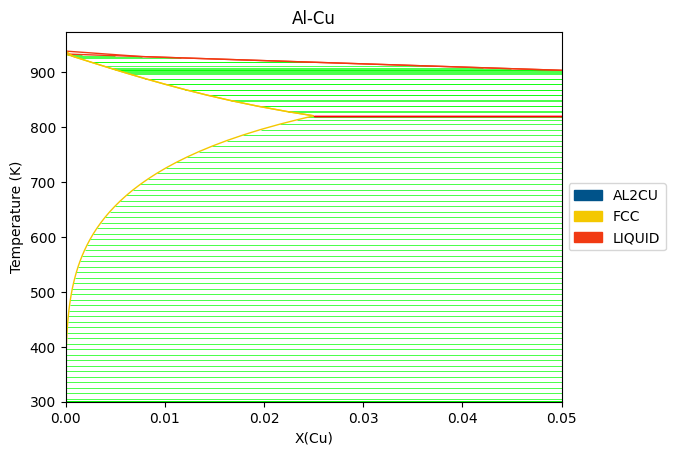

In [4]:
# Generate and plot the phase diagram
phases = ["LIQUID", "FCC", "AL2CU"]
binplot(
    dbf, comps, phases, {v.X("CU"): (0, 0.05, 0.005), v.T: (300, 1000, 10), v.P: 101325, v.N: 1}
)
plt.show()

### Matrix-Al2Cu equilibrium

The first set of parameters we need relates to the equilibrium between the Al-Cu matrix and the Al2Cu precipitates.  Setup the equilibrium calculation as a function of temperature and extract:
1. The equilibrium fraction of Cu in the matrix.
2. The equilibrium fraction of Cu in the precipitate.
3. The chemical potential at equilibrium, as a function of temperature.
4. Post-process the concentration difference between the Cu concentration in the precipitate and the matrix, as a function of temperature.

In [5]:
phases = ["FCC", "AL2CU"]
eq = equilibrium(dbf, comps, phases, {v.X("CU"): initial_cu_fraction, v.T: temperatures, v.P: p, v.N: N})

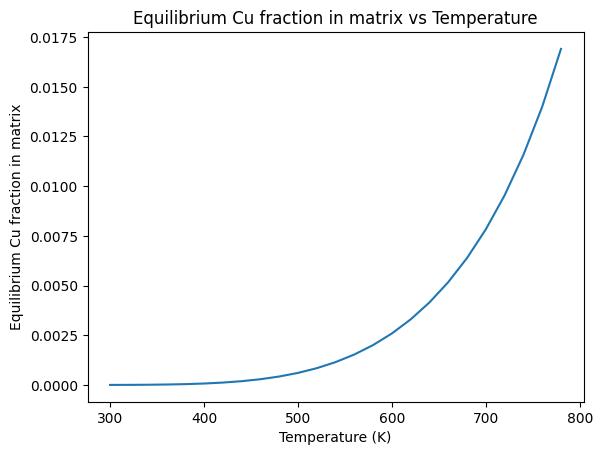

In [6]:
# Extract (and plot) the equilibrium fraction of Cu in the matrix as a function of temperature
temperatures = eq.coords["T"].values
eq_X_Cu_matrix = eq["X"][0,0,:,0,0,1].values
plt.plot(temperatures, eq_X_Cu_matrix)
plt.xlabel("Temperature (K)")
plt.ylabel("Equilibrium Cu fraction in matrix")
plt.title("Equilibrium Cu fraction in matrix vs Temperature")
plt.show()

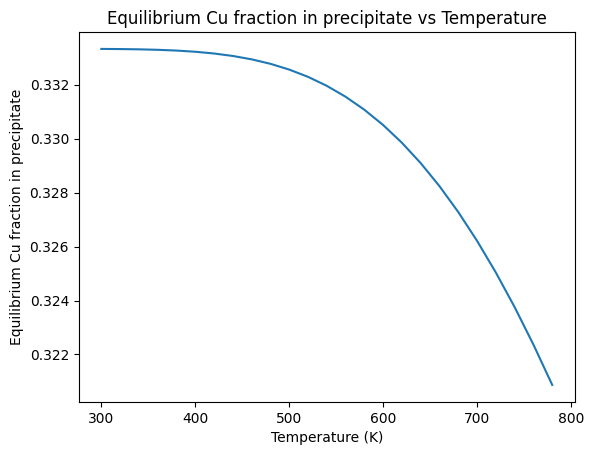

In [7]:
# Extract (and plot) the equilibrium fraction of Cu in the precipitate as a function of temperature
eq_X_Cu_precipitate = eq["X"][0,0,:,0,1,1].values
plt.plot(temperatures, eq_X_Cu_precipitate)
plt.xlabel("Temperature (K)")
plt.ylabel("Equilibrium Cu fraction in precipitate")
plt.title("Equilibrium Cu fraction in precipitate vs Temperature")
plt.show()

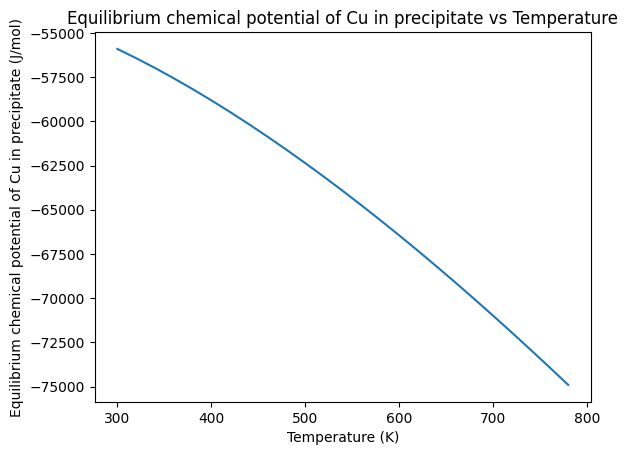

In [8]:
# Extract and plot the checmical potential at equilibrium as a function of temperature
eq_chemical_potential = eq["MU"][0,0,:,0,1].values
plt.plot(temperatures, eq_chemical_potential)
plt.xlabel("Temperature (K)")
plt.ylabel("Equilibrium chemical potential of Cu in precipitate (J/mol)")
plt.title("Equilibrium chemical potential of Cu in precipitate vs Temperature")
plt.show()

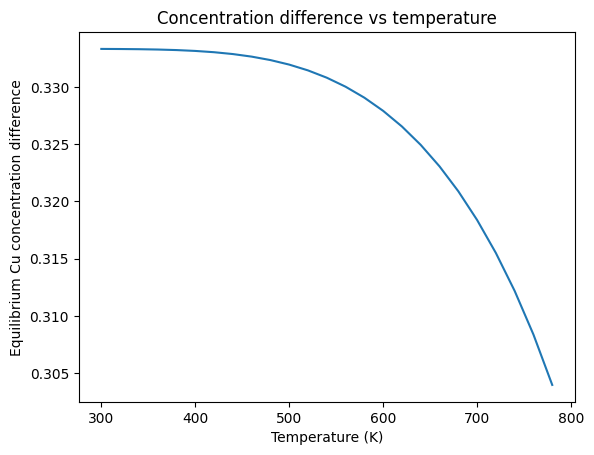

In [9]:
# The actual data that goes into the NEML2 kwn model is the difference in equilibrium concentration between the precipitate and the matrix
eq_concentration_difference = eq_X_Cu_precipitate - eq_X_Cu_matrix
plt.plot(temperatures, eq_concentration_difference)
plt.xlabel("Temperature (K)")
plt.ylabel("Equilibrium Cu concentration difference")
plt.title("Concentration difference vs temperature")
plt.show()

### Matrix chemical potential

Now we need to calculate the chemical potential of the matrix as a function of temperature and Cu concentration.  The difference between the matrix and precipitate equilibrium potential is the chemical driving force for nucleation and growth.

In [10]:
phases = ["FCC"]
eq_matrix = equilibrium(
    dbf, comps, phases, {v.X("CU"): cu_range_consider, v.T: temperatures, v.P: p, v.N: N}
)

In [11]:
# Extract the chemical potential as a function of temperature and Cu concentration in the matrix
matrix_temperatures = eq_matrix.coords["T"].values
matrix_cu_concentrations = eq_matrix.coords["X_CU"].values
matrix_chemical_potential = eq_matrix["MU"][0,0,:,:,1].values

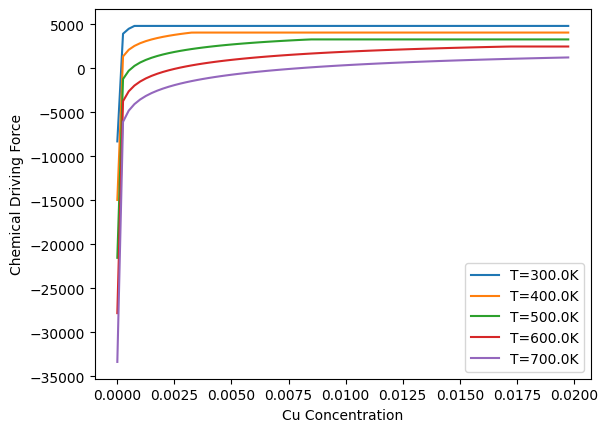

In [12]:
# Now calculate the driving force concentration_difference * (mu_matrix - mu_eq)
chemical_driving_force = (matrix_chemical_potential - eq_chemical_potential[:, np.newaxis]) * eq_concentration_difference[:, np.newaxis]
plt.plot(matrix_cu_concentrations, chemical_driving_force.T[:,::5])
plt.legend([f"T={T}K" for T in temperatures[::5]])
plt.xlabel("Cu Concentration")
plt.ylabel("Chemical Driving Force")
plt.show()

### Print the data we need to copy into the NEML2 model
In addition to what we print out below we need:
1. The molar volume of the precipitate -- calculated stochemetrically as 1.55e12 microns^3/mol
2. The surface energy of the preciptiate -- taken to be around 0.1 J/m^2 based on a glance through the literature.
3. The diffusivity of Cu in Al -- $0.150 \exp\left(\frac{-30200}{RT}\right)$ again based on a quick glance in the literature

In [13]:
print(f"Number of temperature points: {len(temperatures)}")

print("Temperature for interpolation:")
print(" ".join(map(str, temperatures)))
print("Precipitate concentration at equilibrium:")
print(" ".join(map(str, eq_X_Cu_precipitate)))
print("Concentration difference between precipitate and matrix at equilibrium:")
print(" ".join(map(str, eq_concentration_difference)))

Number of temperature points: 25
Temperature for interpolation:
300.0 320.0 340.0 360.0 380.0 400.0 420.0 440.0 460.0 480.0 500.0 520.0 540.0 560.0 580.0 600.0 620.0 640.0 660.0 680.0 700.0 720.0 740.0 760.0 780.0
Precipitate concentration at equilibrium:
0.33332911217881517 0.3333238126869936 0.3333138191818046 0.33329640087553564 0.33326797351227605 0.3332240806181021 0.3331594279875105 0.3330679653231919 0.33294300540917865 0.332777369877488 0.33256355098250034 0.33229388020882944 0.3319606964723173 0.3315565087388985 0.33107414983976596 0.3305069199862039 0.32984871996157666 0.3290941752392994 0.3282387534487308 0.327278878850183 0.3262120490386279 0.3250369613890946 0.32375366053333077 0.32236372488890386 0.3208705231237944
Concentration difference between precipitate and matrix at equilibrium:
0.3333269569608283 0.3333186243432879 0.3333025539858381 0.333273955321312 0.333226368481273 0.3331515445144706 0.3330394141628236 0.33287813608072214 0.3326542061371136 0.3323526044834371 

In [14]:
print("Number of Cu concentration points for interpolation: ", len(matrix_cu_concentrations))

print("Cu concentration for interpolation:")
print(" ".join(map(str, matrix_cu_concentrations)))

print("Chemical potential difference for printing: ")
for row in chemical_driving_force:
    print(" ".join(map(str, row)))

Number of Cu concentration points for interpolation:  80
Cu concentration for interpolation:
1e-10 0.00025 0.0005 0.00075 0.001 0.00125 0.0015 0.00175 0.002 0.0022500000000000003 0.0025 0.00275 0.003 0.0032500000000000003 0.0035 0.00375 0.004 0.00425 0.0045000000000000005 0.00475 0.005 0.00525 0.0055 0.00575 0.006 0.00625 0.006500000000000001 0.00675 0.007 0.00725 0.0075 0.00775 0.008 0.00825 0.0085 0.00875 0.009000000000000001 0.00925 0.0095 0.00975 0.01 0.01025 0.0105 0.010750000000000001 0.011 0.01125 0.0115 0.01175 0.012 0.01225 0.0125 0.012750000000000001 0.013000000000000001 0.01325 0.0135 0.01375 0.014 0.01425 0.0145 0.014750000000000001 0.015 0.01525 0.0155 0.01575 0.016 0.01625 0.0165 0.01675 0.017 0.01725 0.0175 0.017750000000000002 0.018000000000000002 0.01825 0.0185 0.01875 0.019 0.01925 0.0195 0.01975
Chemical potential difference for printing: 
-8296.144775307339 3941.0484895766267 4506.03969086919 4829.582140453553 4829.58214045356 4829.582140453547 4829.58214045354 4829

## Part 2: Calculating a TTP diagram

Now let's use the model to calculate a TTP diagram for the material.  This requires simulating precpitiation over a range of temperatures and times and plotting contours at constant volume fractions of the precipitate.

In [15]:
import torch
import neml2
import tqdm

In [16]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
else:
    dev = "cpu"
device = torch.device(dev)
torch.set_default_device(device)

### Define the conditions to use for calculating the TTP diagram
The TTP diagram is basically a contour plot of the volume fraction of the $\theta$ phase at different conditions of temperature and time.  To calculate the diagram then we need to batch out a large number of KWN simulations of precipitation.

The following cell defines the parameter grid: we chunk out the temperature range of interest and for each temperature run a KWN simulation out the requested time.  The cell also defines the initial conditions for the particle density.  Then we load the model from the `model.i` file.

In [17]:
# Parameters for loading
nsteps = 500
ntemps = 50
nbins = 300
times = torch.logspace(-4,2,nsteps)
temperatures = torch.linspace(300,450,ntemps)
# Start with a very low initial particle density to avoid numerical issues, the model should be insensitive to this as long as it is low enough
ic = torch.full((nbins,), 1e-12)

In [18]:
# Load the model
nmodel = neml2.load_model("model.i", "model")
nmodel.to(device=device)

### Run the simulations
In theory we could run these all at once in a large batch.  However, most systems run out of memory, so instead we'll divide the temperature conditions into smaller temperature chunks, controlled by `temp_chunk`.  Run the batch of temperatures through the full time history for each chunk.

In [19]:
# Temperature chunk size
temp_chunk = 5

# Integrate the model in a loop
# Shape should be (ntemps, nbins)
N = []
vf = []
for j in tqdm.trange(0, ntemps, temp_chunk):
    N.append([])
    vf.append([])
    T = neml2.Scalar(temperatures[j:j+temp_chunk],0)
    for i in range(1, len(times)):
        t_old = neml2.Scalar(times[i-1])
        t_new = neml2.Scalar(times[i])
        if i == 1:
            N_old = neml2.Scalar(ic,0,1)
        else:
            N_old = N[-1][-1]
        updated_state = nmodel.value({"T": T, "t": t_new, "t~1": t_old, "number_density~1": N_old})
        N[-1].append(updated_state["number_density"])
        vf[-1].append(updated_state["vf"])

100%|██████████| 10/10 [1:24:22<00:00, 506.25s/it]


### Consolidate the data and plot

Piece together the subbatches of data and plot the TTP diagram.  In actuality the knee should be about 100 K hotter than what is simulated here, but we didn't calibrate any properties and used a thermodynamic database that might not be optimized for this application

In [48]:
N_full = torch.stack([torch.stack(list(map(lambda x: x.torch(), n))) for n in N]).swapaxes(1,2).flatten(0,1)
vf_full = torch.stack([torch.stack(list(map(lambda x: x.torch(), v))) for v in vf]).swapaxes(1,2).flatten(0,1)

Text(0.5, 1.0, '$\\mathrm{AL}_2\\mathrm{Cu}$ TTP diagram')

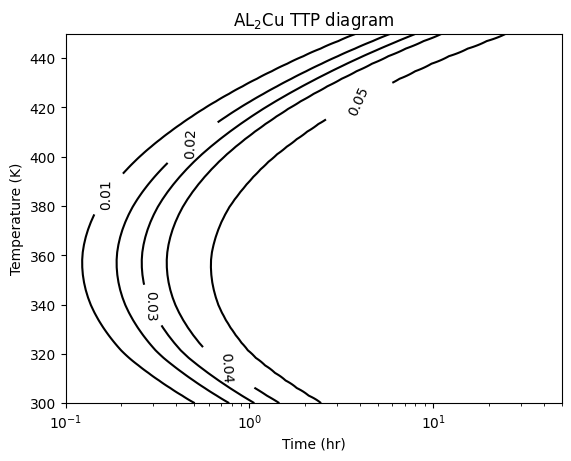

In [50]:
mesh_T, mesh_t = torch.meshgrid(temperatures, times[1:], indexing = 'ij')
CS = plt.contour(mesh_t, mesh_T, vf_full, levels = [0.01,0.02,0.03,0.04,0.05], colors = "k")
plt.clabel(CS, inline=1, fontsize=10)
plt.gca().set_xscale("log")
plt.xlim([1e-1,5e1])
plt.xlabel("Time (hr)")
plt.ylabel("Temperature (K)")
plt.title("$\mathrm{AL}_2\mathrm{Cu}$ TTP diagram")

### Plot some of the number density distributions

This plot shows the number density distribution from the KWN simulations at different temperatures, for the final time step.  It's hard to follow the colors, but you can see the trend indicated by the TTP diagram: you get the highest volume fraction around 360 K, diminishing at temperatures above and below this critical point.

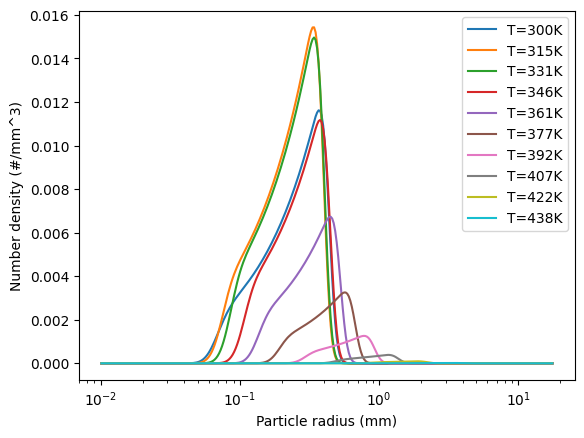

In [52]:
edges = torch.logspace(-2,1.25,nbins+1)
radii = 0.5 * (edges[:-1] + edges[1:])
plt.semilogx(radii, N_full[::5,-1].T, label = [f"T={T:.0f}K" for T in temperatures[::5]])
plt.xlabel("Particle radius (mm)")
plt.ylabel("Number density (#/mm^3)")
plt.legend()